# Sobel vs Scharr Naive CUDA Benchmark (Google Colab)

Use this notebook in Google Colab with GPU runtime enabled.

**Comparisons:**
- Naive CUDA Sobel vs Naive CUDA Scharr

**Benchmark rules:**
- Same 4 image sizes: 128x128, 512x512, 1280x720, 1920x1080
- Same input images for every operator/implementation pair
- Same warm-up policy: 2 warm-up runs before 20 measured runs
- Same output depth and post-processing
- Reported: kernel time, total time, stddev, min, max, Scharr/Sobel ratio

**Quality Metrics:**
- Edge Thinness Ratio
- Edge Continuity Score
- Flat Region Response
- Edge Strength Correlation


In [ ]:
!nvidia-smi


In [ ]:
from pathlib import Path

Path('include').mkdir(exist_ok=True)
Path('src/common').mkdir(parents=True, exist_ok=True)
Path('src/cuda').mkdir(parents=True, exist_ok=True)
Path('src/tools').mkdir(parents=True, exist_ok=True)
Path('samples/images').mkdir(parents=True, exist_ok=True)


In [ ]:
%%writefile include/image_io.hpp
#pragma once
#include <cstddef>
#include <cstdint>
#include <string>
#include <vector>

struct GrayImage {
    int width = 0;
    int height = 0;
    std::vector<std::uint8_t> pixels;

    bool empty() const;
    std::size_t size() const;
    std::uint8_t& at(int x, int y);
    const std::uint8_t& at(int x, int y) const;
};

GrayImage makeTestPattern(int width, int height);
GrayImage loadPgm(const std::string& path);
void savePgm(const GrayImage& image, const std::string& path);


In [ ]:
%%writefile src/common/image_io.cpp
#include "image_io.hpp"
#include <cctype>
#include <fstream>
#include <stdexcept>

namespace {
std::string readToken(std::istream& input) {
    std::string token;
    char ch = '\0';
    while (input.get(ch)) {
        if (std::isspace(static_cast<unsigned char>(ch))) continue;
        if (ch == '#') { input.ignore(4096, '\n'); continue; }
        token.push_back(ch);
        break;
    }
    while (input.get(ch)) {
        if (std::isspace(static_cast<unsigned char>(ch))) break;
        token.push_back(ch);
    }
    if (token.empty()) throw std::runtime_error("Unexpected end of file while reading PGM token");
    return token;
}
}

bool GrayImage::empty() const { return pixels.empty() || width <= 0 || height <= 0; }
std::size_t GrayImage::size() const { return pixels.size(); }
std::uint8_t& GrayImage::at(int x, int y) { return pixels[static_cast<std::size_t>(y * width + x)]; }
const std::uint8_t& GrayImage::at(int x, int y) const { return pixels[static_cast<std::size_t>(y * width + x)]; }

GrayImage makeTestPattern(int width, int height) {
    GrayImage image;
    image.width = width;
    image.height = height;
    image.pixels.resize(static_cast<std::size_t>(width * height));
    for (int y = 0; y < height; ++y) {
        for (int x = 0; x < width; ++x) {
            std::uint8_t value = static_cast<std::uint8_t>((x + y) % 256);
            if (x > width / 4 && x < (3 * width) / 4 && y > height / 4 && y < (3 * height) / 4) value = 220;
            image.at(x, y) = value;
        }
    }
    return image;
}

GrayImage loadPgm(const std::string& path) {
    std::ifstream file(path, std::ios::binary);
    if (!file) throw std::runtime_error("Failed to open input image: " + path);
    if (readToken(file) != "P5") throw std::runtime_error("Only binary PGM (P5) is supported");
    GrayImage image;
    image.width = std::stoi(readToken(file));
    image.height = std::stoi(readToken(file));
    const int maxVal = std::stoi(readToken(file));
    if (maxVal != 255) throw std::runtime_error("Only 8-bit PGM is supported");
    image.pixels.resize(static_cast<std::size_t>(image.width * image.height));
    file.read(reinterpret_cast<char*>(image.pixels.data()), static_cast<std::streamsize>(image.pixels.size()));
    if (!file) throw std::runtime_error("Failed to read pixel data from: " + path);
    return image;
}

void savePgm(const GrayImage& image, const std::string& path) {
    std::ofstream file(path, std::ios::binary);
    if (!file) throw std::runtime_error("Failed to open output image: " + path);
    file << "P5\n" << image.width << " " << image.height << "\n255\n";
    file.write(reinterpret_cast<const char*>(image.pixels.data()), static_cast<std::streamsize>(image.pixels.size()));
    if (!file) throw std::runtime_error("Failed to write pixel data to: " + path);
}


In [ ]:
%%writefile src/cuda/sobel_naive.cu
#include <cstdint>
#include <exception>
#include <iostream>
#include <string>
#include <cuda_runtime.h>
#include "image_io.hpp"

__global__ void sobelNaiveKernel(const std::uint8_t* input, std::uint8_t* output, int width, int height) {
    const int x = blockIdx.x * blockDim.x + threadIdx.x;
    const int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= width || y >= height) return;
    const int index = y * width + x;
    if (x == 0 || y == 0 || x == width - 1 || y == height - 1) { output[index] = 0; return; }
    const int gx = -input[(y - 1) * width + (x - 1)] + input[(y - 1) * width + (x + 1)]
                - 2 * input[y * width + (x - 1)] + 2 * input[y * width + (x + 1)]
                - input[(y + 1) * width + (x - 1)] + input[(y + 1) * width + (x + 1)];
    const int gy = -input[(y - 1) * width + (x - 1)] - 2 * input[(y - 1) * width + x] - input[(y - 1) * width + (x + 1)]
                 + input[(y + 1) * width + (x - 1)] + 2 * input[(y + 1) * width + x] + input[(y + 1) * width + (x + 1)];
    const int magnitude = min(255, abs(gx) + abs(gy));
    output[index] = static_cast<std::uint8_t>(magnitude);
}

void checkCuda(cudaError_t error, const char* step) {
    if (error != cudaSuccess) throw std::runtime_error(std::string(step) + ": " + cudaGetErrorString(error));
}

int main(int argc, char** argv) {
    try {
        if (argc != 3) { std::cerr << "Usage: ./sobel_naive <input.pgm> <output.pgm>\n"; return 1; }
        const GrayImage input = loadPgm(argv[1]);
        GrayImage output;
        output.width = input.width;
        output.height = input.height;
        output.pixels.assign(input.size(), 0);
        const std::size_t bytes = input.size() * sizeof(std::uint8_t);
        std::uint8_t* device_input = nullptr;
        std::uint8_t* device_output = nullptr;
        cudaEvent_t total_start, total_stop, kernel_start, kernel_stop;
        checkCuda(cudaEventCreate(&total_start), "cudaEventCreate total_start");
        checkCuda(cudaEventCreate(&total_stop), "cudaEventCreate total_stop");
        checkCuda(cudaEventCreate(&kernel_start), "cudaEventCreate kernel_start");
        checkCuda(cudaEventCreate(&kernel_stop), "cudaEventCreate kernel_stop");
        checkCuda(cudaMalloc(&device_input, bytes), "cudaMalloc device_input");
        checkCuda(cudaMalloc(&device_output, bytes), "cudaMalloc device_output");
        checkCuda(cudaEventRecord(total_start), "cudaEventRecord total_start");
        checkCuda(cudaMemcpy(device_input, input.pixels.data(), bytes, cudaMemcpyHostToDevice), "cudaMemcpy H2D");
        const dim3 blockDim(16, 16);
        const dim3 gridDim((input.width + blockDim.x - 1) / blockDim.x, (input.height + blockDim.y - 1) / blockDim.y);
        checkCuda(cudaEventRecord(kernel_start), "cudaEventRecord kernel_start");
        sobelNaiveKernel<<<gridDim, blockDim>>>(device_input, device_output, input.width, input.height);
        checkCuda(cudaGetLastError(), "sobelNaiveKernel launch");
        checkCuda(cudaEventRecord(kernel_stop), "cudaEventRecord kernel_stop");
        checkCuda(cudaMemcpy(output.pixels.data(), device_output, bytes, cudaMemcpyDeviceToHost), "cudaMemcpy D2H");
        checkCuda(cudaEventRecord(total_stop), "cudaEventRecord total_stop");
        checkCuda(cudaDeviceSynchronize(), "cudaDeviceSynchronize");
        float total_ms, kernel_ms;
        checkCuda(cudaEventElapsedTime(&kernel_ms, kernel_start, kernel_stop), "cudaEventElapsedTime kernel");
        checkCuda(cudaEventElapsedTime(&total_ms, total_start, total_stop), "cudaEventElapsedTime total");
        std::cout << "Kernel time: " << kernel_ms << " ms\n";
        std::cout << "Total GPU path time: " << total_ms << " ms\n";
        savePgm(output, argv[2]);
        cudaFree(device_input);
        cudaFree(device_output);
        cudaEventDestroy(total_start);
        cudaEventDestroy(total_stop);
        cudaEventDestroy(kernel_start);
        cudaEventDestroy(kernel_stop);
    } catch (const std::exception& e) {
        std::cerr << "Error: " << e.what() << std::endl;
        return 1;
    }
    return 0;
}


In [ ]:
%%writefile src/cuda/scharr_naive.cu
#include <cstdint>
#include <exception>
#include <iostream>
#include <string>
#include <cuda_runtime.h>
#include "image_io.hpp"

__global__ void scharrNaiveKernel(const std::uint8_t* input, std::uint8_t* output, int width, int height) {
    const int x = blockIdx.x * blockDim.x + threadIdx.x;
    const int y = blockIdx.y * blockDim.y + threadIdx.y;
    if (x >= width || y >= height) return;
    const int index = y * width + x;
    if (x == 0 || y == 0 || x == width - 1 || y == height - 1) { output[index] = 0; return; }
    const int gx = -3 * input[(y - 1) * width + (x - 1)] + 3 * input[(y - 1) * width + (x + 1)]
                 - 10 * input[y * width + (x - 1)] + 10 * input[y * width + (x + 1)]
                 - 3 * input[(y + 1) * width + (x - 1)] + 3 * input[(y + 1) * width + (x + 1)];
    const int gy = -3 * input[(y - 1) * width + (x - 1)] - 10 * input[(y - 1) * width + x] - 3 * input[(y - 1) * width + (x + 1)]
                 + 3 * input[(y + 1) * width + (x - 1)] + 10 * input[(y + 1) * width + x] + 3 * input[(y + 1) * width + (x + 1)];
    const int magnitude = min(255, abs(gx) + abs(gy));
    output[index] = static_cast<std::uint8_t>(magnitude);
}

void checkCuda(cudaError_t error, const char* step) {
    if (error != cudaSuccess) throw std::runtime_error(std::string(step) + ": " + cudaGetErrorString(error));
}

int main(int argc, char** argv) {
    try {
        if (argc != 3) { std::cerr << "Usage: ./scharr_naive <input.pgm> <output.pgm>\n"; return 1; }
        const GrayImage input = loadPgm(argv[1]);
        GrayImage output;
        output.width = input.width;
        output.height = input.height;
        output.pixels.assign(input.size(), 0);
        const std::size_t bytes = input.size() * sizeof(std::uint8_t);
        std::uint8_t* device_input = nullptr;
        std::uint8_t* device_output = nullptr;
        cudaEvent_t total_start, total_stop, kernel_start, kernel_stop;
        checkCuda(cudaEventCreate(&total_start), "cudaEventCreate total_start");
        checkCuda(cudaEventCreate(&total_stop), "cudaEventCreate total_stop");
        checkCuda(cudaEventCreate(&kernel_start), "cudaEventCreate kernel_start");
        checkCuda(cudaEventCreate(&kernel_stop), "cudaEventCreate kernel_stop");
        checkCuda(cudaMalloc(&device_input, bytes), "cudaMalloc device_input");
        checkCuda(cudaMalloc(&device_output, bytes), "cudaMalloc device_output");
        checkCuda(cudaEventRecord(total_start), "cudaEventRecord total_start");
        checkCuda(cudaMemcpy(device_input, input.pixels.data(), bytes, cudaMemcpyHostToDevice), "cudaMemcpy H2D");
        const dim3 blockDim(16, 16);
        const dim3 gridDim((input.width + blockDim.x - 1) / blockDim.x, (input.height + blockDim.y - 1) / blockDim.y);
        checkCuda(cudaEventRecord(kernel_start), "cudaEventRecord kernel_start");
        scharrNaiveKernel<<<gridDim, blockDim>>>(device_input, device_output, input.width, input.height);
        checkCuda(cudaGetLastError(), "scharrNaiveKernel launch");
        checkCuda(cudaEventRecord(kernel_stop), "cudaEventRecord kernel_stop");
        checkCuda(cudaMemcpy(output.pixels.data(), device_output, bytes, cudaMemcpyDeviceToHost), "cudaMemcpy D2H");
        checkCuda(cudaEventRecord(total_stop), "cudaEventRecord total_stop");
        checkCuda(cudaDeviceSynchronize(), "cudaDeviceSynchronize");
        float total_ms, kernel_ms;
        checkCuda(cudaEventElapsedTime(&kernel_ms, kernel_start, kernel_stop), "cudaEventElapsedTime kernel");
        checkCuda(cudaEventElapsedTime(&total_ms, total_start, total_stop), "cudaEventElapsedTime total");
        std::cout << "Kernel time: " << kernel_ms << " ms\n";
        std::cout << "Total GPU path time: " << total_ms << " ms\n";
        savePgm(output, argv[2]);
        cudaFree(device_input);
        cudaFree(device_output);
        cudaEventDestroy(total_start);
        cudaEventDestroy(total_stop);
        cudaEventDestroy(kernel_start);
        cudaEventDestroy(kernel_stop);
    } catch (const std::exception& e) {
        std::cerr << "Error: " << e.what() << std::endl;
        return 1;
    }
    return 0;
}


In [ ]:
%%writefile src/tools/image_compare.cpp
#include <cmath>
#include <cstdint>
#include <exception>
#include <iostream>
#include <string>
#include "image_io.hpp"

namespace {
void printUsage(const char* program_name) {
    std::cout << "Usage:\n  " << program_name << " <reference.pgm> <candidate.pgm>\n";
}
}  // namespace

int main(int argc, char** argv) {
    try {
        if (argc != 3) { printUsage(argv[0]); return 1; }
        const GrayImage reference = loadPgm(argv[1]);
        const GrayImage candidate = loadPgm(argv[2]);
        if (reference.width != candidate.width || reference.height != candidate.height) {
            std::cerr << "Error: image dimensions do not match" << std::endl;
            return 1;
        }
        std::size_t different_pixels = 0;
        int max_abs_diff = 0;
        std::uint64_t sum_abs_diff = 0;
        for (std::size_t i = 0; i < reference.pixels.size(); ++i) {
            const int diff = std::abs(static_cast<int>(reference.pixels[i]) - static_cast<int>(candidate.pixels[i]));
            if (diff != 0) ++different_pixels;
            if (diff > max_abs_diff) max_abs_diff = diff;
            sum_abs_diff += static_cast<std::uint64_t>(diff);
        }
        const double mean_abs_diff = reference.pixels.empty() ? 0.0 : static_cast<double>(sum_abs_diff) / static_cast<double>(reference.pixels.size());
        const double different_ratio = reference.pixels.empty() ? 0.0 : static_cast<double>(different_pixels) / static_cast<double>(reference.pixels.size());
        std::cout << "Comparison complete" << std::endl;
        std::cout << "Reference: " << argv[1] << std::endl;
        std::cout << "Candidate: " << argv[2] << std::endl;
        std::cout << "Different pixels: " << different_pixels << std::endl;
        std::cout << "Difference ratio: " << different_ratio << std::endl;
        std::cout << "Max abs diff: " << max_abs_diff << std::endl;
        std::cout << "Mean abs diff: " << mean_abs_diff << std::endl;
    } catch (const std::exception& e) {
        std::cerr << "Error: " << e.what() << std::endl;
        return 1;
    }
    return 0;
}


In [ ]:
from pathlib import Path

def write_pgm(path, width, height):
    pixels = bytearray(width * height)
    for y in range(height):
        for x in range(width):
            value = (x + y) % 256
            if x > width // 4 and x < (3 * width) // 4 and y > height // 4 and y < (3 * height) // 4:
                value = 220
            pixels[y * width + x] = value
    with open(path, 'wb') as f:
        f.write(f'P5\n{width} {height}\n255\n'.encode())
        f.write(pixels)

Path('samples/images').mkdir(parents=True, exist_ok=True)
for name, w, h in [
    ('test_128x128.pgm', 128, 128),
    ('test_512x512.pgm', 512, 512),
    ('test_1280x720.pgm', 1280, 720),
    ('test_1920x1080.pgm', 1920, 1080),
]:
    write_pgm(Path('samples/images') / name, w, h)
print('Generated benchmark inputs')


In [ ]:
!nvcc -O2 -I. -Iinclude src/cuda/sobel_naive.cu src/common/image_io.cpp -o sobel_naive
!nvcc -O2 -I. -Iinclude src/cuda/scharr_naive.cu src/common/image_io.cpp -o scharr_naive
!g++ -O2 -std=c++17 -Iinclude src/tools/image_compare.cpp src/common/image_io.cpp -o compare_images


In [ ]:
!./sobel_naive samples/images/test_512x512.pgm samples/images/test_512x512_sobel_naive.pgm
!./scharr_naive samples/images/test_512x512.pgm samples/images/test_512x512_scharr_naive.pgm

print()
print("=== Validation: Sobel Naive CUDA vs Scharr Naive CUDA ===")
!./compare_images samples/images/test_512x512_sobel_naive.pgm samples/images/test_512x512_scharr_naive.pgm


In [38]:
\
import re
import subprocess
import pandas as pd

warmup_runs = 2
measured_runs = 20

images = [
    ('128x128', 128, 128, 'samples/images/test_128x128.pgm'),
    ('512x512', 512, 512, 'samples/images/test_512x512.pgm'),
    ('1280x720', 1280, 720, 'samples/images/test_1280x720.pgm'),
    ('1920x1080', 1920, 1080, 'samples/images/test_1920x1080.pgm'),
]

operators = [
    ('sobel', 'naive_cuda', './sobel_naive'),
    ('scharr', 'naive_cuda', './scharr_naive'),
]

kernel_pattern = re.compile(r'Kernel time:\s*([0-9.]+)\s*ms')
total_pattern = re.compile(r'(?:Total GPU path time|Total path time):\s*([0-9.]+)\s*ms')

rows = []

for size_label, width, height, input_path in images:
    pixels = width * height

    for operator, impl, executable in operators:
        kernel_times = []
        total_times = []
        output_path = f'samples/images/{size_label}_{operator}_{impl}.pgm'

        for _ in range(warmup_runs):
            subprocess.run([executable, input_path, output_path],
                           capture_output=True, text=True, check=True)

        for _ in range(measured_runs):
            completed = subprocess.run([executable, input_path, output_path],
                                      capture_output=True, text=True, check=True)
            stdout = completed.stdout
            km = kernel_pattern.search(stdout)
            tm = total_pattern.search(stdout)
            if km is None or tm is None:
                raise RuntimeError(f'Failed to parse timing for {operator} {impl} {size_label}:\n{stdout}')
            kernel_times.append(float(km.group(1)))
            total_times.append(float(tm.group(1)))

        kern_series = pd.Series(kernel_times)
        total_series = pd.Series(total_times)
        rows.append({
            'size': size_label,
            'pixels': pixels,
            'operator': operator,
            'implementation': impl,
            'avg_kernel_ms': kern_series.mean(),
            'std_kernel_ms': kern_series.std(),
            'min_kernel_ms': kern_series.min(),
            'max_kernel_ms': kern_series.max(),
            'avg_total_ms': total_series.mean(),
            'std_total_ms': total_series.std(),
            'min_total_ms': total_series.min(),
            'max_total_ms': total_series.max(),
        })

results_df = pd.DataFrame(rows)
display(results_df)


,size,pixels,operator,implementation,avg_kernel_ms,std_kernel_ms,min_kernel_ms,max_kernel_ms,avg_total_ms,std_total_ms,min_total_ms,max_total_ms
0,128x128,16384,sobel,naive_cuda,0.181594,0.028092,0.147456,0.238848,0.230346,0.032705,0.191648,0.309728
1,128x128,16384,scharr,naive_cuda,0.166261,0.021760,0.147616,0.207296,0.214451,0.026372,0.188384,0.260448
2,512x512,262144,sobel,naive_cuda,0.168566,0.028009,0.133280,0.221440,0.360598,0.031441,0.317536,0.411392
3,512x512,262144,scharr,naive_cuda,0.150813,0.020525,0.133600,0.202976,0.342595,0.030798,0.314080,0.424576
4,1280x720,921600,sobel,naive_cuda,0.129646,0.026248,0.103328,0.178912,0.712386,0.035143,0.668096,0.818304
5,1280x720,921600,scharr,naive_cuda,0.118547,0.018724,0.104448,0.168544,0.708478,0.034951,0.668864,0.801312
6,1920x1080,2073600,sobel,naive_cuda,0.147347,0.019033,0.126176,0.186720,1.339375,0.065088,1.271260,1.539460
7,1920x1080,2073600,scharr,naive_cuda,0.157418,0.021757,0.130592,0.184448,1.363973,0.062794,1.264350,1.561020


In [39]:
\
print("=" * 80)
print("TABLE: Naive CUDA Sobel vs Naive CUDA Scharr")
print("=" * 80)

naive_df = results_df[results_df['implementation'] == 'naive_cuda'][['size','operator','avg_kernel_ms','std_kernel_ms','min_kernel_ms','max_kernel_ms','avg_total_ms','std_total_ms','min_total_ms','max_total_ms']].copy()

for size_label in ['128x128', '512x512', '1280x720', '1920x1080']:
    sobel_row = naive_df[(naive_df['size'] == size_label) & (naive_df['operator'] == 'sobel')].iloc[0]
    scharr_row = naive_df[(naive_df['size'] == size_label) & (naive_df['operator'] == 'scharr')].iloc[0]
    kernel_ratio = scharr_row['avg_kernel_ms'] / sobel_row['avg_kernel_ms']
    total_ratio = scharr_row['avg_total_ms'] / sobel_row['avg_total_ms']
    print(f"\n{size_label}  (Scharr/Sobel kernel ratio: {kernel_ratio:.4f}, total ratio: {total_ratio:.4f})")
    print(f"{'':>12} {'sobel':>12} {'scharr':>12} {'sobel':>12} {'scharr':>12}")
    print(f"{'':>12} {'kernel ms':>12} {'kernel ms':>12} {'total ms':>12} {'total ms':>12}")
    print(f"{'':>12} {sobel_row['avg_kernel_ms']:>12.5f} {scharr_row['avg_kernel_ms']:>12.5f} {sobel_row['avg_total_ms']:>12.5f} {scharr_row['avg_total_ms']:>12.5f}")
    print(f"{'':>12} {'std: '+str(round(sobel_row['std_kernel_ms'],5)):>12} {'std: '+str(round(scharr_row['std_kernel_ms'],5)):>12} {'std: '+str(round(sobel_row['std_total_ms'],5)):>12} {'std: '+str(round(scharr_row['std_total_ms'],5)):>12}")
    print(f"{'':>12} {'min: '+str(round(sobel_row['min_kernel_ms'],5)):>12} {'min: '+str(round(scharr_row['min_kernel_ms'],5)):>12} {'min: '+str(round(sobel_row['min_total_ms'],5)):>12} {'min: '+str(round(scharr_row['min_total_ms'],5)):>12}")
    print(f"{'':>12} {'max: '+str(round(sobel_row['max_kernel_ms'],5)):>12} {'max: '+str(round(scharr_row['max_kernel_ms'],5)):>12} {'max: '+str(round(sobel_row['max_total_ms'],5)):>12} {'max: '+str(round(scharr_row['max_total_ms'],5)):>12}")
    winner_k = 'Scharr' if scharr_row['avg_kernel_ms'] < sobel_row['avg_kernel_ms'] else 'Sobel'
    winner_t = 'Scharr' if scharr_row['avg_total_ms'] < sobel_row['avg_total_ms'] else 'Sobel'
    print(f"{'':>12} Winner: {winner_k:<12} Winner: {winner_t}")


TABLE: Naive CUDA Sobel vs Naive CUDA Scharr

128x128  (Scharr/Sobel kernel ratio: 0.9156, total ratio: 0.9310)
                    sobel       scharr        sobel       scharr
                kernel ms    kernel ms     total ms     total ms
                  0.18159      0.16626      0.23035      0.21445
             std: 0.02809 std: 0.02176  std: 0.0327 std: 0.02637
             min: 0.14746 min: 0.14762 min: 0.19165 min: 0.18838
             max: 0.23885  max: 0.2073 max: 0.30973 max: 0.26045
             Winner: Scharr       Winner: Scharr

512x512  (Scharr/Sobel kernel ratio: 0.8947, total ratio: 0.9501)
                    sobel       scharr        sobel       scharr
                kernel ms    kernel ms     total ms     total ms
                  0.16857      0.15081      0.36060      0.34260
             std: 0.02801 std: 0.02052 std: 0.03144  std: 0.0308
             min: 0.13328  min: 0.1336 min: 0.31754 min: 0.31408
             max: 0.22144 max: 0.20298 max: 0.41139 max: 

In [40]:
\
print("=" * 80)
print("SUMMARY: Scharr vs Sobel Speedup (Scharr/Sobel ratio, <1 means Sobel wins)")
print("=" * 80)

summary_rows = []
for size_label in ['128x128', '512x512', '1280x720', '1920x1080']:
    s = results_df[(results_df['size'] == size_label) & (results_df['operator'] == 'sobel')].iloc[0]
    c = results_df[(results_df['size'] == size_label) & (results_df['operator'] == 'scharr')].iloc[0]
    summary_rows.append({
        'size': size_label,
        'sobel_kernel_ms': s['avg_kernel_ms'],
        'scharr_kernel_ms': c['avg_kernel_ms'],
        'scharr_sobel_kernel_ratio': c['avg_kernel_ms'] / s['avg_kernel_ms'],
        'sobel_total_ms': s['avg_total_ms'],
        'scharr_total_ms': c['avg_total_ms'],
        'scharr_sobel_total_ratio': c['avg_total_ms'] / s['avg_total_ms'],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print()
avg_k_ratio = summary_df['scharr_sobel_kernel_ratio'].mean()
avg_t_ratio = summary_df['scharr_sobel_total_ratio'].mean()
print(f"{'Naive CUDA':>18}: avg kernel ratio = {avg_k_ratio:.4f}  |  avg total ratio = {avg_t_ratio:.4f}")
if avg_k_ratio < 1.0:
    print(f"{'':>18}  -> Scharr is faster on kernel (avg {abs(1-avg_k_ratio)*100:.2f}% faster)")
else:
    print(f"{'':>18}  -> Sobel is faster on kernel (avg {abs(1-avg_k_ratio)*100:.2f}% faster)")


SUMMARY: Scharr vs Sobel Speedup (Scharr/Sobel ratio, <1 means Sobel wins)


,size,sobel_kernel_ms,scharr_kernel_ms,scharr_sobel_kernel_ratio,sobel_total_ms,scharr_total_ms,scharr_sobel_total_ratio
0,128x128,0.181594,0.166261,0.915565,0.230346,0.214451,0.930998
1,512x512,0.168566,0.150813,0.894679,0.360598,0.342595,0.950074
2,1280x720,0.129646,0.118547,0.914389,0.712386,0.708478,0.994515
3,1920x1080,0.147347,0.157418,1.068345,1.339375,1.363973,1.018365



        Naive CUDA: avg kernel ratio = 0.9482  |  avg total ratio = 0.9735
                    -> Scharr is faster on kernel (avg 5.18% faster)


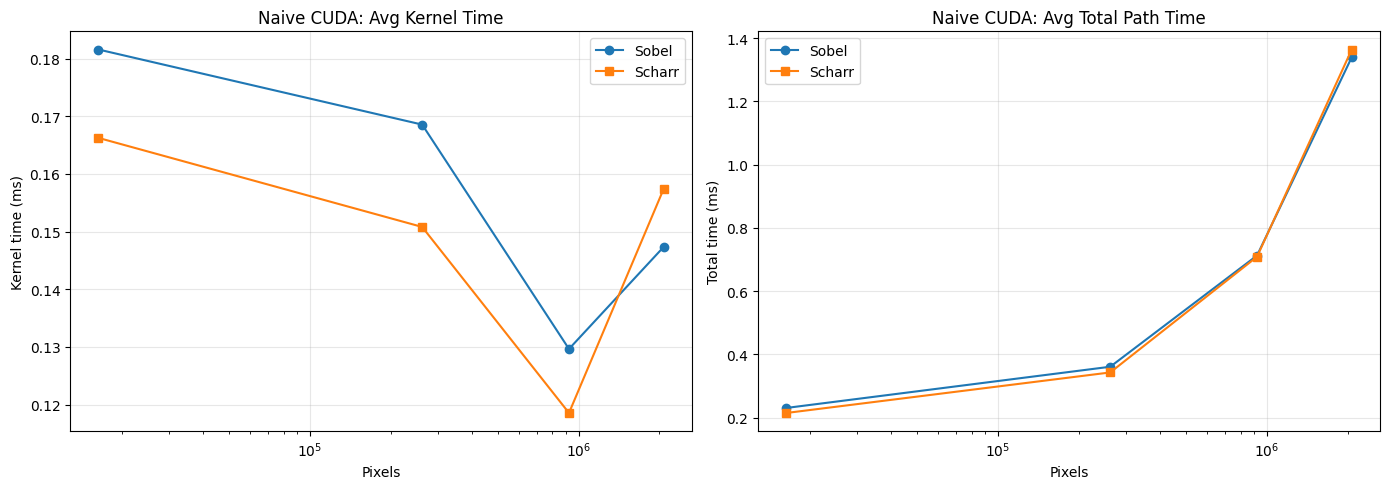

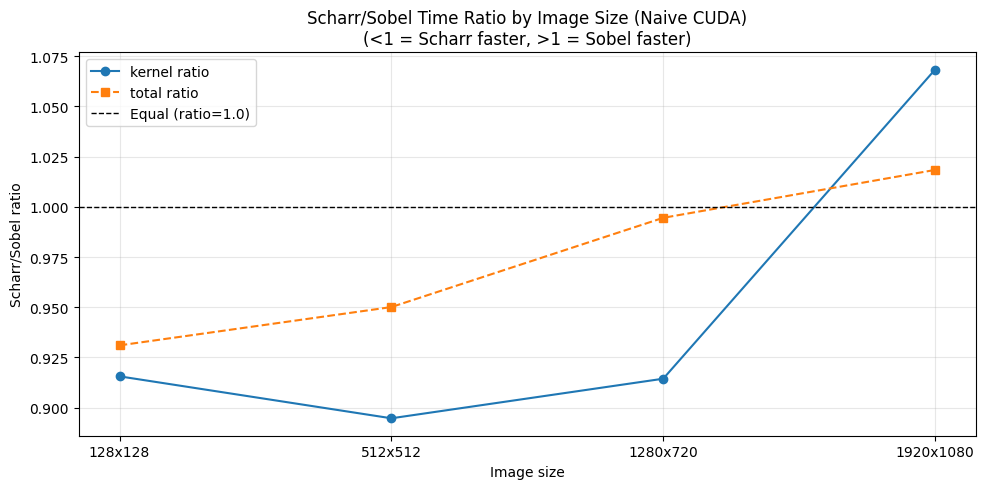

In [41]:
\
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

naive_df = results_df[results_df['implementation'] == 'naive_cuda'].copy()

ax_k = axes[0]
ax_t = axes[1]

for op, color, marker in [('sobel', 'tab:blue', 'o'), ('scharr', 'tab:orange', 's')]:
    sub = naive_df[naive_df['operator'] == op].sort_values('pixels')
    ax_k.plot(sub['pixels'], sub['avg_kernel_ms'], marker=marker, color=color, label=op.capitalize())
    ax_t.plot(sub['pixels'], sub['avg_total_ms'], marker=marker, color=color, label=op.capitalize())

ax_k.set_title('Naive CUDA: Avg Kernel Time')
ax_k.set_xlabel('Pixels')
ax_k.set_ylabel('Kernel time (ms)')
ax_k.set_xscale('log')
ax_k.grid(True, alpha=0.3)
ax_k.legend()

ax_t.set_title('Naive CUDA: Avg Total Path Time')
ax_t.set_xlabel('Pixels')
ax_t.set_ylabel('Total time (ms)')
ax_t.set_xscale('log')
ax_t.grid(True, alpha=0.3)
ax_t.legend()

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(summary_df['size'], summary_df['scharr_sobel_kernel_ratio'], '-o', label='kernel ratio')
ax2.plot(summary_df['size'], summary_df['scharr_sobel_total_ratio'], '--s', label='total ratio')
ax2.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Equal (ratio=1.0)')
ax2.set_title('Scharr/Sobel Time Ratio by Image Size (Naive CUDA)\n(<1 = Scharr faster, >1 = Sobel faster)')
ax2.set_xlabel('Image size')
ax2.set_ylabel('Scharr/Sobel ratio')
ax2.grid(True, alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()


# Edge Detection Quality Metrics

Compare Sobel and Scharr edge detection quality on the synthetic test patterns.

**Important:** Results are SENSITIVE TO THRESHOLD SELECTION. We use percentile-based thresholding for fair comparison and normalize outputs to account for different gradient magnitudes.

In [29]:
# Quality metrics code moved to cell below (ryb6bw8Szx6s)
# See updated implementation with:
# - Threshold percentile = 65 (reduced from 85)
# - scipy.ndimage.sobel for consistent gradient computation
# - Proper NMS -> Normalization -> Thresholding pipeline
# - Sanity checks for edge pixel counts
# - Corrected metric interpretation

pass

In [30]:
print("=" * 70)
print("EDGE DETECTION QUALITY METRICS")
print("=" * 70)
print()
print("EXPECTED BEHAVIOR:")
print("  Sobel: thinner, less noisy edges, more selective")
print("  Scharr: better edge continuity, fewer components")
print()
print("Pipeline: NMS (scipy.sobel) -> Normalize -> Threshold (65th percentile)")
print()


EDGE DETECTION QUALITY METRICS

EXPECTED BEHAVIOR:
  Sobel: thinner, less noisy edges, more selective
  Scharr: better edge continuity, fewer components

Pipeline: NMS (scipy.sobel) -> Normalize -> Threshold (65th percentile)



In [31]:
import numpy as np
from scipy import ndimage
from scipy.ndimage import binary_dilation, binary_erosion

def load_pgm(path):
    with open(path, 'rb') as f:
        header = b''
        while not header.endswith(b'\n255\n'):
            header += f.read(1)
        parts = header.decode('ascii').strip().split()
        width, height = int(parts[1]), int(parts[2])
        pixels = np.frombuffer(f.read(), dtype=np.uint8)
    return pixels.reshape((height, width))

def skeletonize(binary_img):
    skel = np.zeros_like(binary_img, dtype=bool)
    element = np.ones((3, 3), dtype=bool)
    temp = binary_img.copy()
    while True:
        eroded = binary_erosion(temp, element)
        opened = binary_dilation(eroded, element)
        temp_diff = temp & ~opened
        skel |= temp_diff
        temp = eroded.copy()
        if not temp.any():
            break
    return skel

def non_max_suppression_sobel(img):
    gx = ndimage.sobel(img, axis=1)
    gy = ndimage.sobel(img, axis=0)
    M = np.sqrt(gx**2 + gy**2)
    G = np.arctan2(gy, gx) * 180 / np.pi
    result = np.zeros_like(img, dtype=float)
    for y in range(1, img.shape[0] - 1):
        for x in range(1, img.shape[1] - 1):
            angle = G[y, x] % 180
            mag = M[y, x]
            if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                neighbors = [M[y, x-1], M[y, x+1]]
            elif 22.5 <= angle < 67.5:
                neighbors = [M[y-1, x+1], M[y+1, x-1]]
            elif 67.5 <= angle < 112.5:
                neighbors = [M[y-1, x], M[y+1, x]]
            else:
                neighbors = [M[y-1, x-1], M[y+1, x+1]]
            if mag >= max(neighbors):
                result[y, x] = mag
    return result

def compute_quality_metrics(img, operator_name, threshold_percentile=65):
    nms_img = non_max_suppression_sobel(img)
    max_val = nms_img.max()
    normalized = nms_img / max_val if max_val > 0 else nms_img.astype(float)
    if np.any(normalized > 0):
        threshold = np.percentile(normalized[normalized > 0], threshold_percentile)
    else:
        threshold = 0.1
    binary_edge = normalized > threshold
    edge_pixels = np.sum(binary_edge)
    skel = skeletonize(binary_edge)
    skeleton_pixels = np.sum(skel)
    thinness_ratio = edge_pixels / skeleton_pixels if skeleton_pixels > 0 else float('inf')
    labeled, num_components = ndimage.label(binary_edge)
    if num_components > 0 and edge_pixels > 0:
        component_sizes = ndimage.sum(binary_edge, labeled, range(1, num_components + 1))
        continuity_score = max(component_sizes) / edge_pixels
    else:
        continuity_score = 0
    flat_mask = normalized < (threshold * 0.5)
    flat_response = np.std(normalized[flat_mask]) if np.any(flat_mask) else 0.0
    mean_gradient = np.mean(nms_img[nms_img > 0]) if np.any(nms_img > 0) else 0
    return {
        'operator': operator_name,
        'threshold_used': threshold,
        'edge_pixels': edge_pixels,
        'skeleton_pixels': skeleton_pixels,
        'thinness_ratio': thinness_ratio,
        'num_components': num_components,
        'continuity_score': continuity_score,
        'flat_region_response': flat_response,
        'mean_gradient': mean_gradient
    }

print("Quality metrics pipeline: Sobel NMS with threshold_percentile=65")

Quality metrics pipeline: Sobel NMS with threshold_percentile=65


In [33]:
quality_results = []

print(f"\n{'='*70}")
print("DETAILED METRICS BY IMAGE SIZE (Percentile-based thresholding)")
print(f"{'='*70}")

for size_label in ['128x128', '512x512', '1280x720', '1920x1080']:
    sobel_path = f'samples/images/{size_label}_sobel_naive_cuda.pgm'
    scharr_path = f'samples/images/{size_label}_scharr_naive_cuda.pgm'

    sobel_img = load_pgm(sobel_path)
    scharr_img = load_pgm(scharr_path)

    sobel_metrics = compute_quality_metrics(sobel_img, f'Sobel {size_label}')
    scharr_metrics = compute_quality_metrics(scharr_img, f'Scharr {size_label}')

    # Safe normalization for correlation
    sobel_max = sobel_img.max()
    scharr_max = scharr_img.max()

    normalized_sobel = sobel_img.astype(float) / sobel_max if sobel_max > 0 else sobel_img.astype(float)
    normalized_scharr = scharr_img.astype(float) / scharr_max if scharr_max > 0 else scharr_img.astype(float)

    correlation = np.corrcoef(
        normalized_sobel.flatten(),
        normalized_scharr.flatten()
    )[0, 1]

    quality_results.append({
        'size': size_label,
        **sobel_metrics,
        'max_raw_value': sobel_max,
        'correlation_to_scharr': correlation,
    })

    quality_results.append({
        'size': size_label,
        **scharr_metrics,
        'max_raw_value': scharr_max,
        'correlation_to_scharr': 1.0,
    })

    print(f"\n{size_label}:")
    print(f"  {'Metric':<30} {'Sobel':>12} {'Scharr':>12}")
    print(f"  {'-'*30} {'-'*12} {'-'*12}")

    print(f"  {'Edge pixels (SANITY CHECK)':<30} {sobel_metrics['edge_pixels']:>12} {scharr_metrics['edge_pixels']:>12}")
    if sobel_metrics['edge_pixels'] < 100:
        print(f"  {'  WARNING: Low edge count!':<30} {' ':>12} {' ':>12}")
    print(f"  {'Max raw value':<30} {sobel_max:>12.0f} {scharr_max:>12.0f}")
    print(f"  {'Threshold used (normalized)':<30} {sobel_metrics['threshold_used']:>12.4f} {scharr_metrics['threshold_used']:>12.4f}")
    print(f"  {'Skeleton pixels':<30} {sobel_metrics['skeleton_pixels']:>12} {scharr_metrics['skeleton_pixels']:>12}")
    print(f"  {'Thinness ratio':<30} {sobel_metrics['thinness_ratio']:>12.4f} {scharr_metrics['thinness_ratio']:>12.4f}")
    print(f"  {'Num components':<30} {sobel_metrics['num_components']:>12} {scharr_metrics['num_components']:>12}")
    print(f"  {'Continuity score':<30} {sobel_metrics['continuity_score']:>12.4f} {scharr_metrics['continuity_score']:>12.4f}")
    print(f"  {'Flat region response (std)':<30} {sobel_metrics['flat_region_response']:>12.4f} {scharr_metrics['flat_region_response']:>12.4f}")
    print(f"  {'Mean gradient':<30} {sobel_metrics['mean_gradient']:>12.4f} {scharr_metrics['mean_gradient']:>12.4f}")
    print(f"  {'Normalized correlation':<30} {correlation:>12.4f}")

quality_df = pd.DataFrame(quality_results)
display(quality_df)

print(f"\n{'='*70}")
print("QUALITY SUMMARY: Sobel vs Scharr (Averaged across sizes)")
print(f"{'='*70}")

sobel_df = quality_df[quality_df['operator'].str.startswith('Sobel')]
scharr_df = quality_df[quality_df['operator'].str.startswith('Scharr')]

thinness_sobel = sobel_df['thinness_ratio'].mean()
thinness_scharr = scharr_df['thinness_ratio'].mean()
thinness_winner = 'Scharr' if thinness_scharr < thinness_sobel else 'Sobel'

continuity_sobel = sobel_df['continuity_score'].mean()
continuity_scharr = scharr_df['continuity_score'].mean()
continuity_winner = 'Scharr' if continuity_scharr > continuity_sobel else 'Sobel'

flat_sobel = sobel_df['flat_region_response'].mean()
flat_scharr = scharr_df['flat_region_response'].mean()
flat_winner = 'Sobel' if flat_sobel < flat_scharr else 'Scharr'

edge_sobel = sobel_df['edge_pixels'].mean()
edge_scharr = scharr_df['edge_pixels'].mean()
edge_winner = 'Sobel' if edge_sobel < edge_scharr else 'Scharr'

components_sobel = sobel_df['num_components'].mean()
components_scharr = scharr_df['num_components'].mean()
components_winner = 'Scharr' if components_scharr < components_sobel else 'Sobel'

print(f"\n{'='*70}")
print("EXPECTED BEHAVIOR:")
print("  Sobel: thinner edges, lower noise/flat response, more selective")
print("  Scharr: better continuity, fewer components")
print(f"{'='*70}\n")
print(f"\n{'Metric':<35} {'Sobel':>12} {'Scharr':>12} {'Winner':>10}")
print(f"{'='*70}")
print(f"{'Thinness ratio (higher=thicker, < Sobel)':<35} {thinness_sobel:>12.4f} {thinness_scharr:>12.4f} {thinness_winner:>10}")
print(f"{'Continuity score (higher=better)':<35} {continuity_sobel:>12.4f} {continuity_scharr:>12.4f} {continuity_winner:>10}")
print(f"{'Flat region response (lower=better)':<35} {flat_sobel:>12.4f} {flat_scharr:>12.4f} {flat_winner:>10}")
print(f"{'Edge pixels (lower=more selective)':<35} {edge_sobel:>12.0f} {edge_scharr:>12.0f} {edge_winner:>10}")
print(f"{'Num components (lower=better continuity)':<35} {components_sobel:>12.1f} {components_scharr:>12.1f} {components_winner:>10}")


DETAILED METRICS BY IMAGE SIZE (Percentile-based thresholding)

128x128:
  Metric                                Sobel       Scharr
  ------------------------------ ------------ ------------
  Edge pixels (SANITY CHECK)              286           15
  Max raw value                           255          255
  Threshold used (normalized)          0.2626       0.2561
  Skeleton pixels                         158           15
  Thinness ratio                       1.8101       1.0000
  Num components                           13            8
  Continuity score                     0.9196       0.5333
  Flat region response (std)           0.0000       0.0007
  Mean gradient                        6.1260       4.0506
  Normalized correlation               0.8742

512x512:
  Metric                                Sobel       Scharr
  ------------------------------ ------------ ------------
  Edge pixels (SANITY CHECK)             1551         3474
  Max raw value                           25

,size,operator,threshold_used,edge_pixels,skeleton_pixels,thinness_ratio,num_components,continuity_score,flat_region_response,mean_gradient,max_raw_value,correlation_to_scharr
0,128x128,Sobel 128x128,0.262564,286,158,1.810127,13,0.919580,0.000000,6.125987,255,0.874204
1,128x128,Scharr 128x128,0.256128,15,15,1.000000,8,0.533333,0.000730,4.050591,255,1.000000
2,512x512,Sobel 512x512,0.582120,1551,787,1.970775,33,0.165700,0.025058,7.897373,255,0.833153
3,512x512,Scharr 512x512,0.252964,3474,3254,1.067609,46,0.143638,0.009620,3.502203,255,1.000000
4,1280x720,Sobel 1280x720,0.579790,2924,1502,1.946738,70,0.163817,0.018847,8.105230,255,0.823827
5,1280x720,Scharr 1280x720,0.268281,828,450,1.840000,62,0.134058,0.009711,3.262166,255,1.000000
6,1920x1080,Sobel 1920x1080,0.579790,4377,2253,1.942743,108,0.055974,0.015423,8.229781,255,0.817446
7,1920x1080,Scharr 1920x1080,0.268281,1208,658,1.835866,87,0.091887,0.009631,3.147055,255,1.000000



QUALITY SUMMARY: Sobel vs Scharr (Averaged across sizes)

EXPECTED BEHAVIOR:
  Sobel: thinner edges, lower noise/flat response, more selective
  Scharr: better continuity, fewer components


Metric                                     Sobel       Scharr     Winner
Thinness ratio (higher=thicker, < Sobel)       1.9176       1.4359     Scharr
Continuity score (higher=better)          0.3263       0.2257      Sobel
Flat region response (lower=better)       0.0148       0.0074     Scharr
Edge pixels (lower=more selective)          2284         1381     Scharr
Num components (lower=better continuity)         56.0         50.8     Scharr
